# EDA

In [1]:
!pip install -q -r ../requirements.txt

In [2]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

In [3]:
IMAGES_DIR = '../test/images'
OUT_DIR = '../test/output_eda'
os.makedirs(OUT_DIR, exist_ok=True)

#### Размеры по всем 20k

In [4]:
files = sorted(os.listdir(IMAGES_DIR))
ws, hs, modes = [], [], {}
for f in files:
    im = Image.open(os.path.join(IMAGES_DIR, f))
    ws.append(im.width); hs.append(im.height); modes[im.mode] = modes.get(im.mode, 0) + 1
ws, hs = np.array(ws), np.array(hs); ar = ws / hs

print('n =', len(files), 'modes', modes)
for name, a in [('width', ws), ('height', hs), ('aspect w/h', ar)]:
    print(f'{name}: min={a.min():.1f} p5={np.percentile(a,5):.1f} p25={np.percentile(a,25):.1f} med={np.median(a):.1f} p75={np.percentile(a,75):.1f} p95={np.percentile(a,95):.1f} max={a.max():.1f}')
print('vertical (h>w):', (hs > ws).mean())

n = 20000 modes {'RGB': 20000}
width: min=25.0 p5=61.0 p25=129.0 med=238.0 p75=479.2 p95=1047.0 max=1599.0
height: min=10.0 p5=16.0 p25=27.0 med=42.0 p75=76.0 p95=195.0 max=492.0
aspect w/h: min=0.7 p5=2.3 p25=3.5 med=4.9 p75=7.5 p95=14.4 max=49.7
vertical (h>w): 0.0002


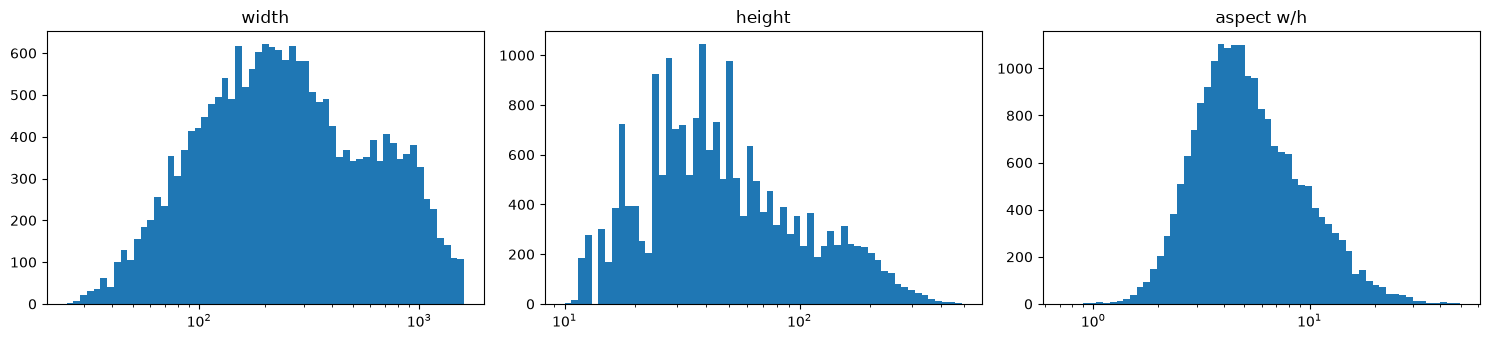

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, (name, a) in zip(axes, [('width', ws), ('height', hs), ('aspect w/h', ar)]):
    ax.hist(a, bins=np.logspace(np.log10(a.min()), np.log10(a.max()), 60))
    ax.set_xscale('log'); ax.set_title(name)
plt.tight_layout()
plt.savefig(OUT_DIR + '/hist.png', dpi=100)
plt.show()

#### Случайная выборка глазами

блюр/шум/сжатие, кириллица/латиница/цифры, сложность фона, обрезки соседних строк

['test_03648.png', 'test_00819.png', 'test_09012.png', 'test_08024.png', 'test_07314.png', 'test_04572.png', 'test_03358.png', 'test_17870.png', 'test_02848.png', 'test_19349.png', 'test_13825.png', 'test_01041.png', 'test_00976.png', 'test_03070.png', 'test_07164.png', 'test_07623.png', 'test_16559.png', 'test_19726.png', 'test_00869.png', 'test_18390.png', 'test_06515.png', 'test_17856.png', 'test_13746.png', 'test_07223.png', 'test_14719.png', 'test_19309.png', 'test_09115.png', 'test_00212.png', 'test_05231.png', 'test_13848.png']


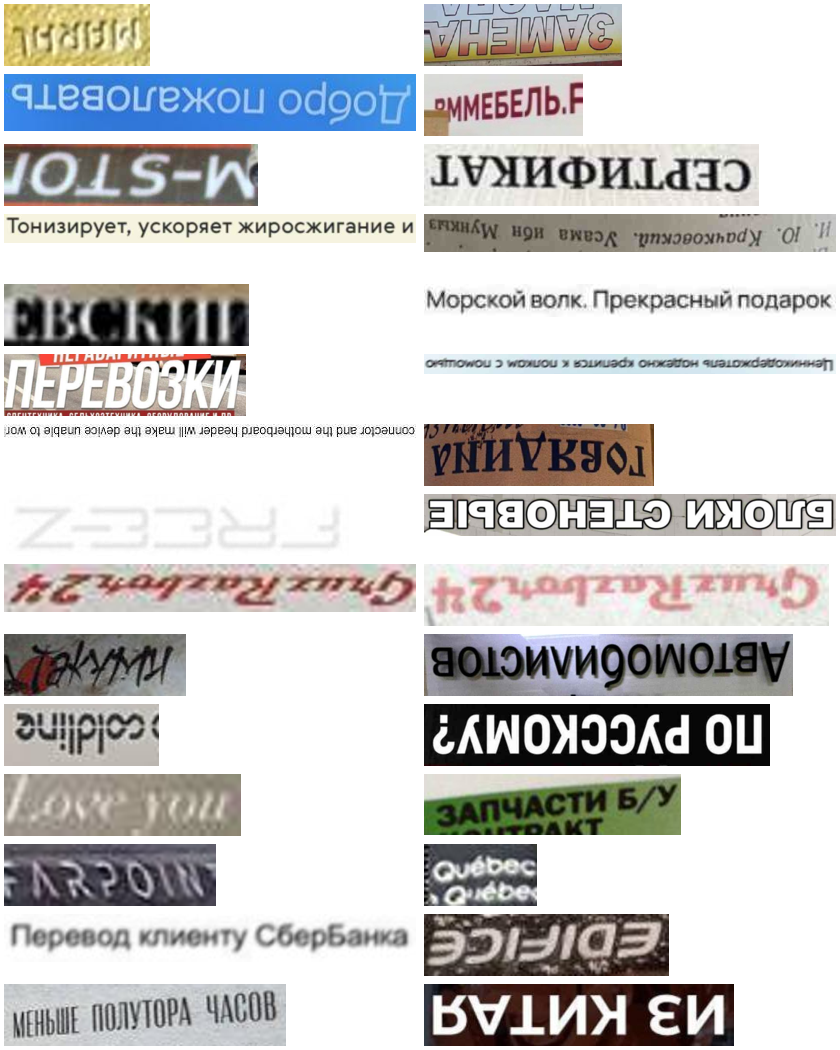

In [6]:
sample = random.sample(files, 30)
W, H = 420, 70
sheet = Image.new('RGB', (W*2, H*15), 'white')
for i, f in enumerate(sample):
    im = Image.open(os.path.join(IMAGES_DIR, f)).convert('RGB')
    s = min((W-8)/im.width, (H-8)/im.height)
    im = im.resize((max(1, int(im.width*s)), max(1, int(im.height*s))))
    sheet.paste(im, ((i%2)*W+4, (i//2)*H+4))
sheet.save(OUT_DIR + '/smoke_sheet.png')
print(sample)
sheet